In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('../data/placement.csv')
print(df.head())


   Unnamed: 0  cgpa     iq  placement
0           0   6.8  123.0          1
1           1   5.9  106.0          0
2           2   5.3  121.0          0
3           3   7.4  132.0          1
4           4   5.8  142.0          0



### Step 2: Data Preprocessing

The column `Unnamed: 0` is redundant as it represents row indices. We remove it.



In [2]:
# Drop the irrelevant index column (Unnamed: 0) using slicing
df = df.iloc[:, 1:]
print(df.head())

# Check for missing values
print(df.isnull().sum())


   cgpa     iq  placement
0   6.8  123.0          1
1   5.9  106.0          0
2   5.3  121.0          0
3   7.4  132.0          1
4   5.8  142.0          0
cgpa         0
iq           0
placement    0
dtype: int64



### Step 3: Exploratory Data Analysis (EDA)

We plot a scatter plot of CGPA vs. IQ, color-coding the points by placement status (Yellow/Red = Placed, Purple/Blue = Not Placed).



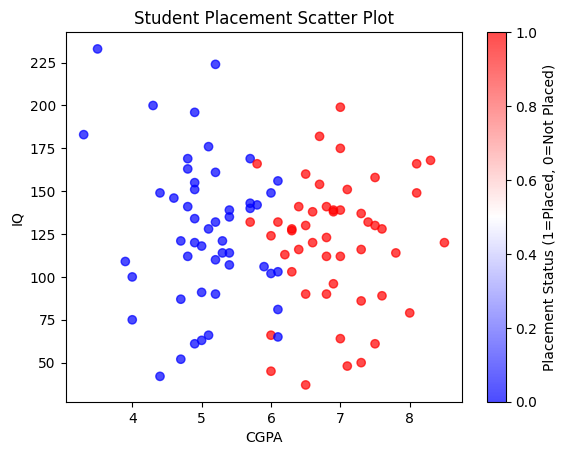

In [3]:
# Scatter plot: CGPA vs IQ, color-coded by placement status
plt.scatter(df['cgpa'], df['iq'], c=df['placement'], cmap='bwr', alpha=0.7)
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('Student Placement Scatter Plot')
plt.colorbar(label='Placement Status (1=Placed, 0=Not Placed)')
plt.show()



### Step 4: Extract Input (X) and Output (y) Features

We separate our independent features (input) from our dependent label (target).



In [4]:
# X contains cgpa and iq columns; y contains the placement column
X = df.iloc[:, 0:2]
y = df.iloc[:, -1]



### Step 5: Train-Test Split

To evaluate our model's performance on unseen data before deploying it to production, we hold back a fraction of our data (10%) for testing.



In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
print("Training Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)


Training Data Size: (90, 2)
Testing Data Size: (10, 2)



### Step 6: Feature Scaling

`cgpa` scales from $0$ to $10$, while `iq` ranges from $50$ to $150$. If we feed this data directly into distance-based or optimization-based algorithms, the larger range of the `iq` column will dominate the calculations. We scale both features to fall within a comparable range (Standardization: Mean = 0, Variance = 1).



In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit and transform the training data, but ONLY transform the testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



### Step 7: Train the Model (Logistic Regression)

Since this is a binary classification problem (Placed vs. Not Placed) and the decision boundary is mostly linear, we train a **Logistic Regression** classifier.



In [7]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

# Train the model
clf.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul


### Step 8: Model Evaluation

We predict on our testing set and calculate the accuracy score.



In [8]:
# Predict on test set
y_pred = clf.predict(X_test_scaled)

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy Score: {accuracy * 100:.2f}%")


Test Accuracy Score: 80.00%



### Step 9: Visualizing the Decision Boundary

We can plot the mathematical line that our trained model uses to divide placed and non-placed students.



In [9]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X_train_scaled, y_train.values, clf=clf, legend=2)
plt.xlabel('Scaled CGPA')
plt.ylabel('Scaled IQ')
plt.title('Logistic Regression Decision Boundary')
plt.show()


ModuleNotFoundError: No module named 'mlxtend'


### Step 10: Model Serialization (Pickling)

To deploy our model inside a web application without retraining it every time, we must serialize (save) the trained model object and our fitted scaler object to disk.



In [ ]:
import pickle

# Save the trained model and scaler to disk
with open('model.pkl', 'wb') as model_file:
    pickle.dump(clf, model_file)

with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)



---

## 3. Web Application Deployment (Streamlit)

Streamlit is a lightweight Python framework used to build and share interactive web apps for machine learning in minutes.

### Web App Script (`app.py`)

Create a file named `app.py`:



In [ ]:
import streamlit as st
import pickle
import numpy as np

# Set page title
st.set_page_config(page_title="Placement Predictor", layout="centered")

st.title("🎓 Student Placement Predictor")
st.write("Predict if a student will get placed based on their academic statistics.")

# Load the saved model and scaler
with open('model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Input UI Fields
cgpa = st.number_input("Enter CGPA (0.0 to 10.0)", min_value=0.0, max_value=10.0, value=7.0, step=0.1)
iq = st.number_input("Enter IQ Score (80 to 150)", min_value=80, max_value=150, value=100, step=1)

# Predict Button
if st.button("Predict Placement"):
    # 1. Format the input data as a 2D array
    input_data = np.array([[cgpa, iq]])

    # 2. Scale the input data using the loaded scaler
    scaled_data = scaler.transform(input_data)

    # 3. Predict using the loaded model
    prediction = model.predict(scaled_data)

    # 4. Display Result
    if prediction[0] == 1:
        st.success("🎉 Congratulations! The model predicts the student will get PLACED!")
    else:
        st.warning("⚠️ The model predicts the student will NOT get placed. Keep working hard!")



### Running the App

To launch the app locally:

```bash
streamlit run app.py
```

This launches a local web server at `http://localhost:8501/`, which can then be deployed to cloud hosting platforms like **Heroku**, **AWS**, or **GCP**.
